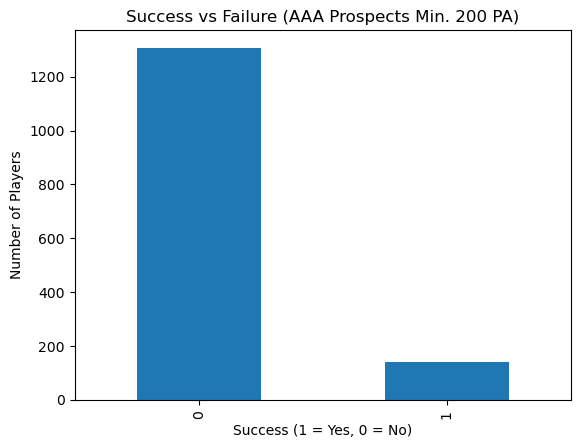

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/final_dataset.csv")

df["success"].value_counts().plot(kind="bar")
plt.title("Success vs Failure (AAA Prospects Min. 200 PA)")
plt.xlabel("Success (1 = Yes, 0 = No)")
plt.ylabel("Number of Players")
plt.show()

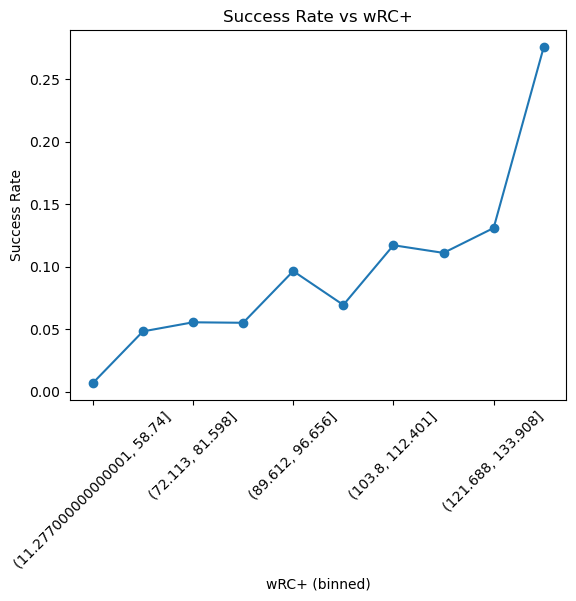

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/final_dataset.csv")

df["wRC_bin"] = pd.qcut(df["wRC+"], q=10)

success_rate = df.groupby("wRC_bin")["success"].mean()

success_rate.plot(kind="line", marker="o")
plt.title("Success Rate vs wRC+")
plt.xlabel("wRC+ (binned)")
plt.ylabel("Success Rate")
plt.xticks(rotation=45)
plt.show()

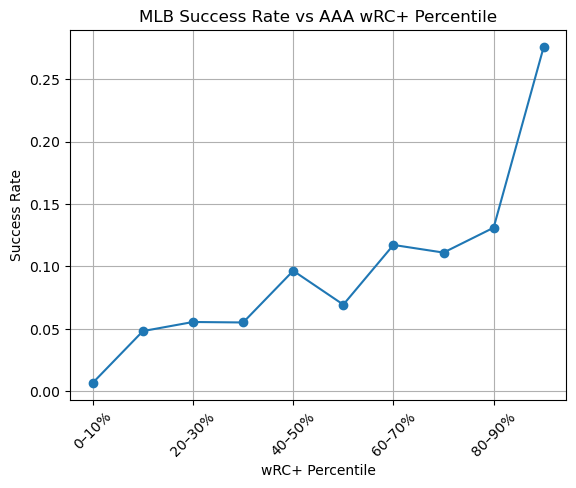

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/final_dataset.csv")

import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Create percentile rank (0 → 1) ---
df["wRC_percentile"] = df["wRC+"].rank(pct=True)

# --- 2. Bin into 10 groups (deciles) ---
df["wRC_pct_bin"] = pd.qcut(df["wRC_percentile"], q=10)

# --- 3. Make labels readable (0–10%, 10–20%, etc.) ---
df["wRC_pct_bin"] = df["wRC_pct_bin"].apply(
    lambda x: f"{int(x.left * 100)}–{int(x.right * 100)}%"
)

# --- 4. Compute success rate in each bin ---
success_rate = df.groupby("wRC_pct_bin")["success"].mean()

# --- 5. Sort bins correctly (important for plotting order) ---
success_rate = success_rate.sort_index()

# --- 6. Plot ---
plt.figure()
success_rate.plot(marker="o")

plt.title("MLB Success Rate vs AAA wRC+ Percentile")
plt.xlabel("wRC+ Percentile")
plt.ylabel("Success Rate")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

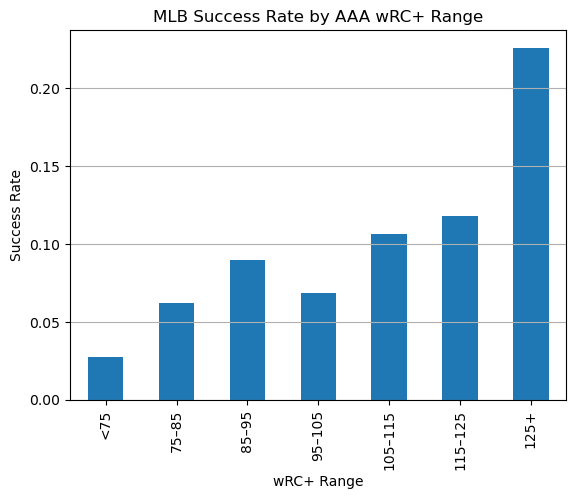

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Define bins ---
bins = [0, 75, 85, 95, 105, 115, 125, 200]
labels = ["<75", "75–85", "85–95", "95–105", "105–115", "115–125", "125+"]

# --- 2. Assign bins ---
df["wRC_bin"] = pd.cut(df["wRC+"], bins=bins, labels=labels, include_lowest=True)

# --- 3. Compute success rate ---
success_rate = df.groupby("wRC_bin")["success"].mean()

# ensure all bins show up (even if empty)
success_rate = success_rate.reindex(labels)

# --- 4. Plot ---
plt.figure()
success_rate.plot(kind="bar")

plt.title("MLB Success Rate by AAA wRC+ Range")
plt.xlabel("wRC+ Range")
plt.ylabel("Success Rate")
plt.grid(axis="y")

plt.show()

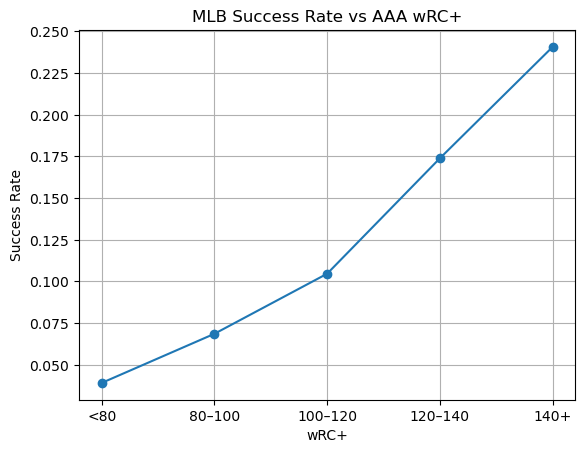

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Define bins ---
bins = [0, 80, 100, 120, 140, 200]
labels = ["<80", "80–100", "100–120", "120–140", "140+"]

# --- 2. Assign bins ---
df["wRC_bin"] = pd.cut(df["wRC+"], bins=bins, labels=labels, include_lowest=True)

# --- 3. Compute success rate ---
success_rate = df.groupby("wRC_bin")["success"].mean()

# --- 4. Create numeric x-axis (midpoints of bins) ---
x_vals = [70, 90, 110, 130, 150]  # approximate centers

# --- 5. Plot ---
plt.figure()
plt.plot(x_vals, success_rate.values, marker="o")

plt.title("MLB Success Rate vs AAA wRC+")
plt.xlabel("wRC+")
plt.ylabel("Success Rate")

# Show labels under points
plt.xticks(x_vals, labels)

plt.grid(True)
plt.show()

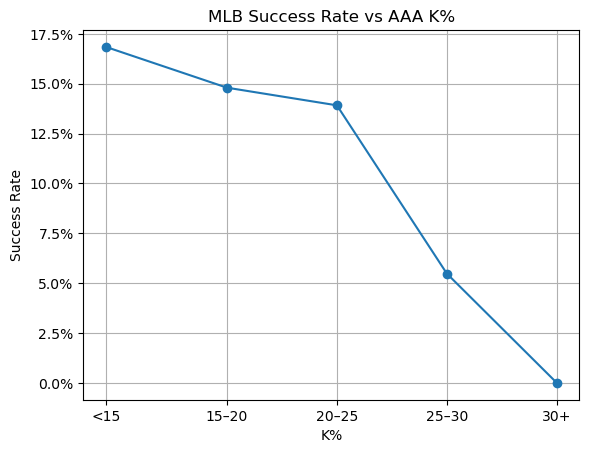

In [23]:
import matplotlib.ticker as mtick

bins = [0, 0.15, 0.20, 0.25, 0.30, 0.40]
labels = ["<15", "15–20", "20–25", "25–30", "30+"]
x_vals = [0.12, 0.175, 0.225, 0.275, 0.325]

df["K%_bin"] = pd.cut(df["K%"], bins=bins, labels=labels, include_lowest=True)

success_rate = df.groupby("K%_bin", observed=False)["success"].mean()
success_rate = success_rate.reindex(labels)

plt.figure()
plt.plot(x_vals, success_rate.values, marker="o")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(x_vals, labels)
plt.title("MLB Success Rate vs AAA K%")
plt.xlabel("K%")
plt.ylabel("Success Rate")
plt.grid(True)
plt.show()